# Notebook 3, minimal version: MSR analysis of HPA repositories

This notebook is a reduced version of the third notebook of the empirical pipeline on the use of the Kubernetes Horizontal Pod Autoscaler (HPA) in open-source projects. It supports the paper and keeps only the blocks needed for the analysis of repository activity, HPA file stability, configuration richness, smell indicators, sensitivity, and commit co-evolution.

Execution assumes that the artifacts of the previous notebooks are already available under `data/`:

```text
1_mine_hpa_usage.ipynb: collection, mining, and enrichment of the corpus
2_classify_hpa_minimal_version.ipynb: classification of the HPA manifests, HFRS, and configuration fields
3_msr_repository_analysis_minimal_version.ipynb: MSR analysis of activity, smells, and sensitivity
```

## Overview of this minimal version

This version does not contain every exploratory analysis of the full notebook. It keeps the sections used directly as support for the paper, together with the checks needed to reproduce the main tables, printed values, and figures.

| Section | Content | Role in the analysis |
|---|---|---|
| **0. Google Colab bootstrap** | Prepares the environment on Colab or for a local run | Reproducibility |
| **1. Setup and loading** | Loads datasets, constants, helper functions, and output paths | Preparation |
| **2. Scope of the minimal version** | Explains which blocks were preserved and which were removed | Organization |
| **3. Repository activity and HPA file stability** | Measures repository age, HPA file age, and the frozen-HPA pattern | RQ3 |
| **4. Comparison between active and outdated repositories** | Runs the statistical tests and prints the supporting tables | RQ3 |
| **5. HFRS and repository activity** | Compares configuration richness across maintenance statuses | RQ3 |
| **6. Sensitivity of the version distribution** | Checks whether the version composition changes under corpus filters | Robustness |
| **7. Smell indicators** | Computes R1 to R8 and produces the consistency tables | RQ4 |
| **8. HFRS sensitivity per scenario** | Compares HFRS under filters of activity, age, stars, and commit year | Robustness |
| **9. Commit frequency on HPA files** | Analyzes how often HPA files were modified in the Phase 6 sample | RQ3 |
| **10. Temporal co-evolution of commits** | Measures the proximity between HPA commits and general repository commits | RQ3 |
| **11. Final check** | Confirms that the expected artifacts were produced | Execution control |

## Required input data

| File | Main use |
|---|---|
| `hpa_repo_aggregated.csv` | Repository metadata, activity, stars, counts, and status |
| `phase4_latest.csv` | Classified HPA files, versions, metrics, and configuration fields |
| `phase3_file_commits_latest.csv` | Last commit per HPA file, used to measure the actual file age |
| `hpa_hfrs.csv` | HFRS and its subdimensions per HPA file, used by the smell indicators |
| `hpa_hfrs_full.csv` | HFRS enriched with repository and commit metadata |
| `phase6_commit_timeline_latest.csv` | Commit events for the HPA-touch frequency analysis |
| `phase6_coevolution.csv` | Temporal distance between HPA commits and general repository commits |

## A note on the textual results

The quantitative values shown in the sections are recomputed by the code cells. When a table depends directly on the corpus, this version favors the printed output and the tables produced at run time, which avoids keeping duplicated numbers in markdown that could go stale after a new collection or an update of the CSV files.


## 0. Google Colab bootstrap

This section prepares the notebook for execution on Google Colab and keeps compatibility with a local run in VS Code or Jupyter.

When running on Colab, the notebook uses the temporary environment of the session itself by default:

```text
/content/hpa
```

That path does not depend on the Google Drive account of the original project. The required files are downloaded from the version-specific artifact record on Zenodo, with the GitHub repository as a fallback, including `requirements.txt`, `data.zip` and, when needed, `repos_history.zip`.

The bootstrap performs the following tasks:

1. detects whether the notebook is running on Google Colab or locally;
2. sets the project root to `/content/hpa` on Colab, or to the current directory in a local run;
3. creates the minimal directory structure of the project;
4. downloads `requirements.txt` when the file is not in the root;
5. installs the dependencies;
6. downloads `data.zip` when the main CSV files are missing;
7. extracts `data.zip` into `PROJECT_DIR/data`;
8. extracts `data/repos_history.zip` into `data/repos_history` when needed;
9. validates the main files before moving on.

For this notebook, the validation covers the files used by the MSR analysis, the smell indicators, and the temporal sections:

```text
hpa_repo_aggregated.csv
phase4_latest.csv
phase3_file_commits_latest.csv
hpa_hfrs.csv
hpa_hfrs_full.csv
phase6_commit_timeline_latest.csv
phase6_coevolution.csv
```

To store outputs persistently, the project path can be overridden before running the bootstrap:

```python
import os
os.environ["HPA_PROJECT_DIR"] = "/content/drive/MyDrive/Colab Notebooks/hpa"
```

In that case Drive serves only as a persistent working location. Otherwise the notebook runs under `/content/hpa`, which Colab recreates on every new session.


In [1]:
# ============================================================
# Google Colab bootstrap, compatible with local VSCode/Jupyter
# ============================================================

import os
import sys
import subprocess
import zipfile
import shutil
from pathlib import Path
from urllib.request import urlretrieve

IN_COLAB = "google.colab" in sys.modules

# Where the bootstrap downloads data.zip and repos_history.zip when they are not
# already present, which is the case in a fresh Google Colab runtime. A local run
# from the downloaded package needs no download, because data/ ships with it.
#
# The version-specific Zenodo record is the reference source. Set HPA_ARTIFACT_BASE_URL
# to override it, for example to test against the development repository:
#
#     os.environ["HPA_ARTIFACT_BASE_URL"] = "https://raw.githubusercontent.com/CallyCa/hpa_usage/main"
#
# Zenodo file URLs follow https://zenodo.org/records/<RECORD_ID>/files/<name>
ZENODO_RECORD_ID = os.environ.get("HPA_ZENODO_RECORD_ID", "22134989").strip()
ZENODO_BASE_URL = f"https://zenodo.org/records/{ZENODO_RECORD_ID}/files"
GITHUB_BASE_URL = "https://raw.githubusercontent.com/CallyCa/hpa_usage/main"

BASE_URL = os.environ.get("HPA_ARTIFACT_BASE_URL", ZENODO_BASE_URL).rstrip("/")

DATA_ZIP_URL = f"{BASE_URL}/data.zip"
REPOS_HISTORY_ZIP_URL = f"{BASE_URL}/repos_history.zip"
REQUIREMENTS_URL = f"{BASE_URL}/requirements.txt"

# You may override this path before running the cell, for example:
# os.environ["HPA_PROJECT_DIR"] = "/content/drive/MyDrive/Colab Notebooks/hpa"
if IN_COLAB:
    # Default: temporary Colab storage, faster and independent from Google Drive.
    DEFAULT_PROJECT_DIR = Path("/content/hpa")

    # If you want persistent outputs in Google Drive, uncomment this block
    # and override HPA_PROJECT_DIR before running the bootstrap.
    #
    # from google.colab import drive
    # try:
    #     drive.mount("/content/drive")
    # except Exception:
    #     drive.mount("/content/drive", force_remount=True)
    # DEFAULT_PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/hpa")
else:
    DEFAULT_PROJECT_DIR = Path.cwd()

PROJECT_DIR = Path(os.environ.get("HPA_PROJECT_DIR", str(DEFAULT_PROJECT_DIR))).expanduser()
DATA_DIR = PROJECT_DIR / "data"
REPOS_HIST_DIR = DATA_DIR / "repos_history"
PLOTS_DIR = DATA_DIR / "figures" / "notebook-3"


def _safe_mkdir(path: Path) -> None:
    try:
        path.mkdir(parents=True, exist_ok=True)
    except OSError as exc:
        raise OSError(
            f"Could not create/access {path}. "
            "If this is Google Colab with Drive mounted, the Drive mount may be stale. "
            "Use Runtime > Restart runtime, run the bootstrap again, and approve the Drive mount."
        ) from exc


for _p in [PROJECT_DIR, DATA_DIR, PLOTS_DIR]:
    _safe_mkdir(_p)

try:
    os.chdir(PROJECT_DIR)
except OSError as exc:
    raise OSError(
        f"Could not switch to PROJECT_DIR={PROJECT_DIR}. "
        "If this is Google Colab with Drive mounted, restart the runtime and rerun this bootstrap cell."
    ) from exc

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"Running in Colab: {IN_COLAB}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")
print(f"Plots directory:   {PLOTS_DIR}")


def _pip_install(*packages: str) -> None:
    if not packages:
        return
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *packages],
        check=True,
    )


def _download_file(url: str, output_file: Path, description: str) -> bool:
    """Download a file, falling back to the development repository.

    The version-specific Zenodo record is tried first. If it is unreachable,
    the GitHub mirror is used instead, so a fresh Colab runtime still works.
    """
    output_file.parent.mkdir(parents=True, exist_ok=True)

    candidates = [url]
    if url.startswith(ZENODO_BASE_URL):
        candidates.append(url.replace(ZENODO_BASE_URL, GITHUB_BASE_URL))

    for candidate in candidates:
        print(f"Downloading {description} from {candidate}...")
        try:
            urlretrieve(candidate, output_file)
            if output_file.exists() and output_file.stat().st_size > 0:
                return True
        except Exception as exc:
            print(f"Could not download {description} from {candidate}.")
            print(f"Details: {exc}")

    return False


def _has_core_data() -> bool:
    required = [
        "hpa_repo_aggregated.csv",
        "phase4_latest.csv",
        "phase3_file_commits_latest.csv",
        "hpa_hfrs_full.csv",
        "phase6_commit_timeline_latest.csv",
        "phase6_coevolution.csv",
    ]
    return all((DATA_DIR / name).exists() for name in required)


def _copy_tree_contents(src_dir: Path, dst_dir: Path) -> None:
    dst_dir.mkdir(parents=True, exist_ok=True)

    for item in src_dir.iterdir():
        target = dst_dir / item.name

        if item.is_dir():
            shutil.copytree(item, target, dirs_exist_ok=True)
        else:
            shutil.copy2(item, target)


def _extract_data_zip(zip_path: Path) -> None:
    """
    Extract data.zip robustly whether it contains:
    1) data/<files>
    2) <files> directly
    3) one top-level folder containing data/<files>
    """
    if not zip_path.exists():
        return

    tmp_dir = PROJECT_DIR / "_tmp_data_extract"

    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)

    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {zip_path.name}...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    candidates = [tmp_dir / "data"]

    top_dirs = [p for p in tmp_dir.iterdir() if p.is_dir()]

    if len(top_dirs) == 1:
        candidates.append(top_dirs[0] / "data")
        candidates.append(top_dirs[0])

    candidates.append(tmp_dir)

    src_data = None

    for cand in candidates:
        if cand.exists() and (cand / "phase4_latest.csv").exists():
            src_data = cand
            break

    if src_data is None:
        for cand in candidates:
            if cand.exists() and any(cand.glob("*.csv")):
                src_data = cand
                break

    if src_data is None:
        raise FileNotFoundError(
            f"Could not find CSV files inside {zip_path}. Check the data.zip structure."
        )

    _copy_tree_contents(src_data, DATA_DIR)
    shutil.rmtree(tmp_dir, ignore_errors=True)

    print(f"Data extracted to {DATA_DIR}")


def _extract_repos_history_zip(zip_path: Path) -> None:
    if not zip_path.exists():
        return

    if REPOS_HIST_DIR.exists() and any(REPOS_HIST_DIR.iterdir()):
        print(f"repos_history already available at {REPOS_HIST_DIR}")
        return

    tmp_dir = DATA_DIR / "_tmp_repos_history_extract"

    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)

    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {zip_path.name}...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    candidates = [tmp_dir / "repos_history"]

    top_dirs = [p for p in tmp_dir.iterdir() if p.is_dir()]

    if len(top_dirs) == 1:
        candidates.append(top_dirs[0] / "repos_history")
        candidates.append(top_dirs[0])

    candidates.append(tmp_dir)

    src_hist = next(
        (p for p in candidates if p.exists() and any(p.iterdir())),
        None,
    )

    if src_hist is None:
        raise FileNotFoundError(
            f"Could not locate repos_history content inside {zip_path}"
        )

    REPOS_HIST_DIR.mkdir(parents=True, exist_ok=True)
    _copy_tree_contents(src_hist, REPOS_HIST_DIR)
    shutil.rmtree(tmp_dir, ignore_errors=True)

    print(f"repos_history extracted to {REPOS_HIST_DIR}")


# 1) Ensure requirements.txt exists before dependency installation.
requirements_path = PROJECT_DIR / "requirements.txt"

if not requirements_path.exists():
    ok = _download_file(REQUIREMENTS_URL, requirements_path, "requirements.txt")

    if not ok:
        print("requirements.txt could not be downloaded. Installing minimal dependencies.")

# 2) Install dependencies.
if requirements_path.exists():
    print("Installing dependencies from requirements.txt...")
    _pip_install("-r", str(requirements_path))
else:
    _pip_install(
        "pandas",
        "matplotlib",
        "seaborn",
        "scipy",
        "pyyaml",
        "python-dotenv",
        "requests",
        "joblib",
        "GitPython",
    )

# Extra packages used by plotting/statistical sections.
_pip_install("seaborn", "scipy", "requests")

# 3) Ensure core data exists.
if not _has_core_data():
    data_zip = PROJECT_DIR / "data.zip"

    if not data_zip.exists():
        ok = _download_file(DATA_ZIP_URL, data_zip, "complete data.zip")

        if not ok:
            raise FileNotFoundError(
                "Could not download data.zip automatically. "
                "Place data.zip in the project root or manually copy the data/ folder to PROJECT_DIR/data."
            )

    _extract_data_zip(data_zip)

# 4) Ensure repos_history exists.
# Preferred source: data/repos_history.zip, if it came inside data.zip.
# Fallback source: GitHub repos_history.zip.
repos_zip = DATA_DIR / "repos_history.zip"

if not (REPOS_HIST_DIR.exists() and any(REPOS_HIST_DIR.iterdir())):
    if not repos_zip.exists():
        ok = _download_file(REPOS_HISTORY_ZIP_URL, repos_zip, "repos_history.zip")

        if not ok:
            raise FileNotFoundError(
                "Could not download repos_history.zip automatically. "
                "Place repos_history.zip inside PROJECT_DIR/data."
            )

    _extract_repos_history_zip(repos_zip)

# 5) Final validation.
print("\nValidation summary")
print("- requirements.txt:", "OK" if requirements_path.exists() else "missing")
print("- Core data:       ", "OK" if _has_core_data() else "missing one or more required CSV files")
print("- repos_history:   ", str(REPOS_HIST_DIR) if REPOS_HIST_DIR.exists() else "not available")
print("- Project dir:     ", str(PROJECT_DIR))
print("- Plots dir:       ", str(PLOTS_DIR))

if not _has_core_data():
    required = [
        "hpa_repo_aggregated.csv",
        "phase4_latest.csv",
        "phase3_file_commits_latest.csv",
        "hpa_hfrs_full.csv",
        "phase6_commit_timeline_latest.csv",
        "phase6_coevolution.csv",
    ]

    missing = [
        name
        for name in required
        if not (DATA_DIR / name).exists()
    ]

    raise FileNotFoundError(
        "Missing required data files after bootstrap: " + ", ".join(missing)
    )

Running in Colab: False
Project directory: /home/calendario2009/Downloads/characterizing-hpa-usage-open-source
Data directory:    /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data
Plots directory:   /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/figures/notebook-3
Installing dependencies from requirements.txt...

Validation summary
- requirements.txt: OK
- Core data:        OK
- repos_history:    /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/repos_history
- Project dir:      /home/calendario2009/Downloads/characterizing-hpa-usage-open-source
- Plots dir:        /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/figures/notebook-3


## 1. Setup and loading

This section loads the libraries, defines the constants, creates the helper functions, and reads the datasets needed by the minimal version of the notebook.

The reference date `REF_DATE = 2026-03-07` is the date used by the collection pipeline. It supports the temporal measures `pushed_age_years`, `repo_age_years`, `hpa_file_age_years` and `file_lag_years`. Keeping this date fixed makes the notebook reproduce the same temporal window analyzed in the paper.

Main temporal fields:

| Field | Level | Interpretation |
|---|---|---|
| `pushed_age_years` | Repository | Age of the last push to the repository |
| `repo_age_years` | Repository | Approximate age of the repository since creation |
| `hpa_file_age_years` | HPA file | Age of the last commit that touched the HPA file |
| `file_lag_years` | HPA file | Difference between the HPA file age and the repository recency |

The `hpa_file_age_years` measure is preferred for analyzing HPA maintenance because it observes the configuration file directly. The `pushed_age_years` measure captures general repository activity and can mask HPA files that stayed static while the project kept receiving commits.


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR  = Path('data')
PLOTS_DIR = DATA_DIR / 'figures' / 'notebook-3'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.30,
    'grid.linestyle':    '--',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':    9,
})

VERSION_COLORS = {
    'v1':      '#E65100',
    'v2beta1': '#7B1FA2',
    'v2beta2': '#2E7D32',
    'v2':      '#1565C0',
    'other':   '#757575',
    'unknown': '#9E9E9E',
}

def map_version(api):
    if not isinstance(api, str): return 'unknown'
    if 'v2beta2' in api: return 'v2beta2'
    elif 'v2beta1' in api: return 'v2beta1'
    elif 'v2' in api: return 'v2'
    elif 'v1' in api: return 'v1'
    return 'other'


def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def savefig(name):
    p = PLOTS_DIR / name
    plt.savefig(p, dpi=150, bbox_inches='tight')
    print(f'Salvo: {p}')

print('Setup complete.')

Setup complete.


In [3]:
# ── Carregar datasets ──────────────────────────────────────────────────────

repos = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
repos['created_at'] = pd.to_datetime(repos['created_at'], errors='coerce', utc=True).dt.tz_localize(None)
repos['pushed_at']  = pd.to_datetime(repos['pushed_at'],  errors='coerce', utc=True).dt.tz_localize(None)

p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
p4 = p4[p4['Is Helm Template'] == False].copy()
p4 = p4.rename(columns={
    'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path',
    'Is Helm Template': 'is_helm_template', 'Has Behavior': 'has_behavior',
    'Metric Type': 'metric_type', 'Metric Name': 'metric_name',
})
p4['repo_full_name'] = p4['owner'].astype(str) + '/' + p4['project'].astype(str)

classify = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
classify = classify[classify['Is Helm Template'] == False].copy()

# ── Dados de commit por arquivo HPA (Phase 3.5) ────────────────────────────
_fc_path = DATA_DIR / 'phase3_file_commits_latest.csv'
if _fc_path.exists():
    df_file_commits = pd.read_csv(_fc_path)
    df_file_commits['file_last_commit'] = pd.to_datetime(
        df_file_commits['file_last_commit'], errors='coerce', utc=True
    ).dt.tz_localize(None)
    df_file_commits = df_file_commits.rename(columns={
        'Owner': 'owner', 'Project': 'project', 'File Path': 'file_path'
    })
    HAS_FILE_COMMITS = True
    print(f'phase3_file_commits: {len(df_file_commits):,} arquivos  '
          f'({df_file_commits["file_last_commit"].notna().sum():,} com data real)')
else:
    df_file_commits = None
    HAS_FILE_COMMITS = False
    print('Warning: phase3_file_commits_latest.csv not found.')
    print('       Run Phase 3.5 in 1_mine_hpa_usage.ipynb.')
    print('       Análises de atividade usarão pushed_at como proxy.')

# ── Data de referência ─────────────────────────────────────────────────────
REF_DATE = pd.Timestamp('2026-03-07')

print(f'\nData de referência (coleta): {REF_DATE.date()}')
print(f'Repositórios no corpus:      {len(repos):,}')
print(f'Arquivos HPA (phase4):       {len(p4):,}')
print(f'Linhas classify:             {len(classify):,}')

phase3_file_commits: 9,770 arquivos  (9,770 com data real)

Data de referência (coleta): 2026-03-07
Repositórios no corpus:      12,741
Arquivos HPA (phase4):       16,506
Linhas classify:             16,506


In [4]:
# ── Enriquecer repos com métricas derivadas ────────────────────────────────

repos['repo_age_years']    = (REF_DATE - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['pushed_age_years']  = (REF_DATE - repos['pushed_at']).dt.total_seconds() / (365.25 * 86400)
repos['lifespan_years']    = (repos['pushed_at'] - repos['created_at']).dt.total_seconds() / (365.25 * 86400)
repos['has_hpa_data']      = repos['metrics_count'].notna()

# Repos que têm dados HPA coletados (phase3/4 encontrou algo)
repos_hpa = repos[repos['has_hpa_data']].copy()

# ── Adicionar hpa_file_age_years por repositório ───────────────────────────
# hpa_file_age_years: idade do arquivo HPA modificado mais recentemente dentro do repo.
# Diferente de pushed_age_years (repo inteiro), reflete quando o HPA foi de fato tocado.
# Fonte: phase3_file_commits_latest.csv (Phase 3.5).

if HAS_FILE_COMMITS:
    # Por repositório: usar o arquivo HPA com commit mais recente (menor idade)
    _fc_repo = (
        df_file_commits
        .assign(repo_full_name=lambda d: d['owner'].astype(str) + '/' + d['project'].astype(str))
        .groupby('repo_full_name')['file_last_commit']
        .max()   # max date = min age = arquivo mais recentemente modificado
        .reset_index()
    )
    _fc_repo['hpa_file_age_years'] = (
        (REF_DATE - _fc_repo['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    repos_hpa = repos_hpa.merge(
        _fc_repo[['repo_full_name', 'hpa_file_age_years']],
        on='repo_full_name', how='left'
    )
    # Gap: quanto o arquivo HPA ficou parado enquanto o repo foi atualizado
    repos_hpa['hpa_lag_years'] = (
        repos_hpa['hpa_file_age_years'] - repos_hpa['pushed_age_years']
    ).clip(lower=0)
    _n_real = repos_hpa['hpa_file_age_years'].notna().sum()
    print(f'hpa_file_age_years (dados reais): {_n_real:,}/{len(repos_hpa):,} repos')
    print(f'  Mediana: {repos_hpa["hpa_file_age_years"].median():.2f} anos')
    print(f'  Repos com HPA lag ≥ 1yr: {(repos_hpa["hpa_lag_years"] >= 1).sum():,}')
else:
    # mesma coisa que pushed_age_years
    repos_hpa['hpa_file_age_years'] = repos_hpa['pushed_age_years']
    repos_hpa['hpa_lag_years']      = 0.0
    print('hpa_file_age_years = pushed_age_years (Phase 3.5 was not run)')

print(f'\nRepos com dados HPA: {len(repos_hpa):,}  ({len(repos_hpa)/len(repos)*100:.2f}%)')
print(repos_hpa[['repo_age_years', 'pushed_age_years', 'hpa_file_age_years']].describe().round(2))

hpa_file_age_years (dados reais): 7,013/7,013 repos
  Mediana: 0.80 anos
  Repos com HPA lag ≥ 1yr: 715

Repos com dados HPA: 7,013  (55.04%)
       repo_age_years  pushed_age_years  hpa_file_age_years
count         7012.00           7012.00             7013.00
mean             1.83              1.23                1.59
std              2.07              1.65                1.86
min             -0.13             -0.13                0.00
25%              0.34              0.06                0.24
50%              0.98              0.62                0.80
75%              2.55              1.68                2.23
max             13.80              9.66                9.66


## 2. Scope of the minimal version

This reduced version keeps only the blocks of Notebook 3 that support the results reported in the paper. The focus is on repository activity, HPA file stability, HFRS by maintenance status, smell indicators, sensitivity analyses, Phase 6, and commit co-evolution.

Exploratory figures and analyses that the paper does not need were removed. The preserved blocks still use the same datasets as the full notebook, with a simplified organization that eases execution on Google Colab.

This minimal version does not replace the full notebook. It serves as a reproduction and validation path for the essential results.


## 3. Repository activity and HPA file stability

### 3.1 Source of the activity data

With Phase 3.5 executed, the `hpa_file_age_years` field reflects when the HPA file was last modified. The value comes from the most recent commit that touched the HPA file path.

Separating repository activity from HPA file activity is necessary because `pushed_at` reflects any commit in the repository. A project may stay active and still keep the HPA manifest unchanged for years.

| Field | Level | What it measures |
|---|---|---|
| `pushed_age_years` | Repository | Years since any push to the repository |
| `hpa_file_age_years` | File | Years since the last commit that touched the HPA file |
| `file_lag_years` | File | Difference between the HPA file age and the repository recency |

A positive `file_lag_years` means the HPA file is older than the recent activity of the repository. High values indicate that the project evolved while the scaling configuration stood still.


### 3.2 The `toy_any` helper variable

The minimal version does not keep the full analysis of educational projects, examples, demos, and tests. It still builds `toy_any`, because some sensitivity analyses use that variable to separate potentially demonstrative or educational repositories from the rest.

Here `toy_any` is treated only as a helper variable. The detailed interpretation of toy projects belongs to the full notebook.


In [5]:
# ── Sinais de toy project via nome do repositório ──────────────────────────
# Baseado em: Kalliamvakou et al. (2014), Munaiah et al. (2017) "Curating GitHub"
# Categorias de keywords:

TOY_KEYWORDS = {
    'educational': ['tutorial', 'course', 'learn', 'exercise', 'workshop', 'lecture', 'study'],
    'example':     ['example', 'sample', 'demo', 'showcase', 'starter', 'boilerplate', 'template'],
    'test':        ['test', 'playground', 'sandbox', 'experiment', 'poc', 'proof-of-concept'],
    'practice':    ['practice', 'training', 'kata', 'challenge', 'homework', 'assignment'],
}

# Aplicar sobre o nome do projeto (segunda parte de owner/project)
def extract_project_name(repo_full_name):
    parts = str(repo_full_name).split('/', 1)
    return parts[1].lower() if len(parts) == 2 else str(repo_full_name).lower()

repos_hpa = repos_hpa.copy()
repos_hpa['project_name_lower'] = repos_hpa['repo_full_name'].apply(extract_project_name)

for category, keywords in TOY_KEYWORDS.items():
    pattern = '|'.join(keywords)
    repos_hpa[f'toy_{category}'] = repos_hpa['project_name_lower'].str.contains(
        pattern, regex=True, na=False
    )

repos_hpa['toy_any'] = repos_hpa[[f'toy_{c}' for c in TOY_KEYWORDS]].any(axis=1)

print('Flags de toy project (contagem de repositórios):')
print(f'  toy_any (pelo menos 1 sinal): {repos_hpa["toy_any"].sum():,}  '
      f'({repos_hpa["toy_any"].sum()/len(repos_hpa)*100:.2f}%)')
for c in TOY_KEYWORDS:
    n = repos_hpa[f'toy_{c}'].sum()
    print(f'  toy_{c:<13} {n:>5,}  ({n/len(repos_hpa)*100:.2f}%)')

print('\nExemplos de repos sinalizados como toy:')
print(repos_hpa[repos_hpa['toy_any']][['repo_full_name','toy_educational',
    'toy_example','toy_test','toy_practice']].head(15))

Flags de toy project (contagem de repositórios):
  toy_any (pelo menos 1 sinal): 966  (13.77%)
  toy_educational     241  (3.44%)
  toy_example         344  (4.91%)
  toy_test            194  (2.77%)
  toy_practice        195  (2.78%)

Exemplos de repos sinalizados como toy:
                                        repo_full_name  toy_educational  \
14                         12Venky/DevOps-Assignment-2            False   
15                           181192/katacoda-scenarios            False   
19                           1jashshah/DEVOPS_TRAINING            False   
20                                   1k-off/aidlc-demo            False   
21                        1lucascq/fiap_tech_challenge            False   
22   1lucascq/fiap_tech_challenge_kubernetes_terraform            False   
39                         3sergey/kubernetes-practice            False   
56                            6SOATGP54/tech-challenge            False   
57                 6SOATGP54/tech-challenge-ms-pr

In [6]:
# ── Construir dataset para análise de atividade ────────────────────────────

p4_files = p4.drop_duplicates(subset=['owner','project','file_path']).copy()
p4_files['VersionGroup'] = p4_files['apiVersion'].apply(map_version)
p4_files = p4_files.merge(
    repos_hpa[['repo_full_name','pushed_age_years','repo_age_years',
               'lifespan_years','stargazers_count','v2_ratio','toy_any',
               'hpa_file_age_years','hpa_lag_years']],
    on='repo_full_name', how='left'
)

# Add file_last_commit per file, at file granularity rather than repository granularity
if HAS_FILE_COMMITS:
    p4_files = p4_files.merge(
        df_file_commits[['owner','project','file_path','file_last_commit']],
        on=['owner','project','file_path'], how='left'
    )
    p4_files['file_age_years'] = (
        (REF_DATE - p4_files['file_last_commit'])
        .dt.total_seconds() / (365.25 * 86400)
    ).clip(lower=0)
    # Gap por arquivo: repo pushed_age vs este arquivo específico
    p4_files['file_lag_years'] = (
        p4_files['file_age_years'] - p4_files['pushed_age_years']
    ).clip(lower=0)
else:
    p4_files['file_last_commit'] = None
    p4_files['file_age_years']   = p4_files['pushed_age_years']
    p4_files['file_lag_years']   = 0.0

print(f'p4_files enriquecido: {len(p4_files):,} linhas')
if HAS_FILE_COMMITS:
    _n_real = p4_files['file_last_commit'].notna().sum()
    print(f'  file_last_commit real: {_n_real:,}/{len(p4_files):,} ({_n_real/len(p4_files)*100:.2f}%)')
    print(f'  file_lag_years mediana: {p4_files["file_lag_years"].median():.2f} anos')
print(p4_files.head().to_string())

p4_files enriquecido: 9,764 linhas
  file_last_commit real: 9,764/9,764 (100.00%)
  file_lag_years mediana: 0.06 anos
           owner                  project                                     file_path  is_helm_template           apiVersion ScaleTargetRef Kind  has_behavior  Behavior ScaleUp StabilizationWindow Behavior ScaleUp SelectPolicy Behavior ScaleUp Policies Behavior ScaleDown StabilizationWindow Behavior ScaleDown SelectPolicy Behavior ScaleDown Policies MinReplicas MaxReplicas metric_type metric_name  Target Kind Target Value ContainerResource Container                      repo_full_name VersionGroup  pushed_age_years  repo_age_years  lifespan_years  stargazers_count  v2_ratio  toy_any  hpa_file_age_years  hpa_lag_years    file_last_commit  file_age_years  file_lag_years
0  snakierboss52           k8s-kode-cloud                           k8s/apache-hpa.yaml             False       autoscaling/v2          Deployment         False                                   NaN     

### 3.3 The frozen-HPA pattern in an active repository

This section computes the frozen-HPA pattern in active repositories. The pattern occurs when the repository remains active while the HPA file does not follow that activity.

Criteria used:

| Criterion | Interpretation |
|---|---|
| `pushed_age_years <= 2` | The repository received recent activity |
| `file_lag_years >= lag_threshold` | The HPA file lags behind the repository |
| `hpa_file_age_years` available | The age is computed at the HPA file level |

The next cell prints the totals, the prevalence, and the distribution per API version. These values are recomputed at run time to avoid divergence between the markdown and the current data.


In [7]:
# ── Números citados no artigo: padrão HPA congelado ──────────────────────────
# Recomputa diretamente de p4_files para independência de ordem de execução
_at = 2.0   # active_threshold (anos)
_lt = 1.0   # lag_threshold (anos)
_p4_active = p4_files[p4_files['pushed_age_years'] <= _at]
_total_act = len(_p4_active)

if HAS_FILE_COMMITS and 'file_lag_years' in p4_files.columns:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['file_lag_years'] >= _lt)
    ]
    _method = 'direto (file_lag_years)'
else:
    _stable = p4_files[
        (p4_files['pushed_age_years'] <= _at) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['v2_ratio'].fillna(1) == 0.0)
    ]
    _method = 'proxy (v2_ratio=0)'

print('\n--- ARTIGO: padrão HPA congelado em repo ativo ---')
print(f'  active_threshold: {_at}yr  |  lag_threshold: {_lt}yr')
print(f'  Método de detecção: {_method}')
print(f'  Total arquivos em repos ativos (pushed <= {_at}yr): {_total_act:,}')
print(f'  Padrão stable: {len(_stable):,}  ({len(_stable)/_total_act*100:.2f}%)')
print(f'  → Artigo: {len(_stable):,} arquivos stable ({len(_stable)/_total_act*100:.2f}% dos {_total_act:,} ativos)')



--- ARTIGO: padrão HPA congelado em repo ativo ---
  active_threshold: 2.0yr  |  lag_threshold: 1.0yr
  Método de detecção: direto (file_lag_years)
  Total arquivos em repos ativos (pushed <= 2.0yr): 7,758
  Padrão stable: 729  (9.40%)
  → Artigo: 729 arquivos stable (9.40% dos 7,758 ativos)


In [8]:
# ── Identificar "HPA estável em repositório ativo" ─────────────────────────

active_threshold = 2.0   # anos para o repo ser considerado ativo
lag_threshold    = 1.0   # anos de lag mínimo para considerar HPA "estável"

if HAS_FILE_COMMITS:
    # Critério direto: usa dados reais de commit por arquivo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years']  <= active_threshold) &
        (p4_files['file_lag_years']    >= lag_threshold)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'direct (file_lag_years)'
else:
    # Critério proxy: v1 ou v2beta em repo ativo
    stable_hpa_active_repo = p4_files[
        (p4_files['pushed_age_years'] <= active_threshold) &
        (p4_files['VersionGroup'] != 'v2') &
        (p4_files['VersionGroup'] != 'unknown') &
        (p4_files['v2_ratio'] == 0.0)
    ].copy()
    stable_hpa_active_repo['detection_method'] = 'proxy (v2_ratio=0)'

total_active = (p4_files['pushed_age_years'] <= active_threshold).sum()

print(f'Método de detecção: {stable_hpa_active_repo["detection_method"].iloc[0] if len(stable_hpa_active_repo) else "n/a"}')
print(f'Arquivos HPA em repos ativos (pushed ≤ {active_threshold}yr): {total_active:,}')
print(f'Padrão "stable HPA": {len(stable_hpa_active_repo):,}  '
      f'({len(stable_hpa_active_repo)/total_active*100:.2f}%)')
print()
print('Distribuição por version group:')
print(stable_hpa_active_repo['VersionGroup'].value_counts())
print()
print('Distribuição por apiVersion bruto:')
print(stable_hpa_active_repo['apiVersion'].value_counts())

if HAS_FILE_COMMITS:
    print()
    print('file_lag_years (anos de gap) nos casos detectados:')
    print(stable_hpa_active_repo['file_lag_years'].describe().round(2))

Método de detecção: direct (file_lag_years)
Arquivos HPA em repos ativos (pushed ≤ 2.0yr): 7,758
Padrão "stable HPA": 729  (9.40%)

Distribuição por version group:
VersionGroup
v2         286
v1         260
v2beta2    117
v2beta1     65
unknown      1
Name: count, dtype: int64

Distribuição por apiVersion bruto:
apiVersion
autoscaling/v2         286
autoscaling/v1         258
autoscaling/v2beta2    117
autoscaling/v2beta1     65
v1                       2
Name: count, dtype: int64

file_lag_years (anos de gap) nos casos detectados:
count    729.00
mean       2.76
std        1.55
min        1.00
25%        1.49
50%        2.30
75%        3.61
max        9.06
Name: file_lag_years, dtype: float64


### 3.4 Reading the frozen-HPA pattern

The frozen-HPA pattern in an active repository is evidence of uneven maintenance: the project keeps evolving while the scaling configuration stays unchanged.

The technical reading depends on the API version and on the configuration richness. A frozen HPA under `autoscaling/v1` suggests retention of a legacy API. A frozen HPA under `autoscaling/v2` indicates that migrating the version does not by itself guarantee continued maintenance or effective use of the newer capabilities.

The quantitative values of this section should be read from the output of the previous cells, since they depend directly on the CSV files loaded.


## 4. Comparison between active and outdated repositories (RQ3)

This section compares repositories classified as **Active**, **In-between** and **Outdated**. The classification uses the recency of repository maintenance and shows whether active repositories tend to use more recent or more elaborate HPA configurations.

Status criteria:

| Status | Criterion | Interpretation |
|---|---|---|
| **Active** | `last_commit_age_years <= 2` | Recent activity |
| **In-between** | `2 < last_commit_age_years <= 3` | Intermediate zone |
| **Outdated** | `last_commit_age_years > 3` | Low recent activity |

Hypotheses tested with a one-sided Mann-Whitney U test:

| Hypothesis | Metric | Expectation |
|---|---|---|
| H1 | `v2_ratio` | Active repositories tend to show higher v2 adoption |
| H2 | `behavior_any` | Active repositories tend to use `spec.behavior` more often |
| H3 | `stargazers_count` | More popular repositories would tend to be more active |
| H4 | `metrics_count` | Active repositories would tend to use more metrics |

The test is non-parametric because the distributions are skewed, with many zeros and long tails.


In [9]:
# ── Números citados no artigo: comparação ativo vs. inativo ──────────────────
_act_r  = repos_hpa[repos_hpa['is_active'] == True]
_out_r  = repos_hpa[repos_hpa['is_outdated'] == True]
_inbet_r = repos_hpa[(repos_hpa['is_active'] == False) & (repos_hpa['is_outdated'] == False)]

print('\n--- ARTIGO: Active/Outdated dentro de repos_hpa ---')
print(f'  repos_hpa total: {len(repos_hpa):,}')
print(f'  Active:     {len(_act_r):,}  ({len(_act_r)/len(repos_hpa)*100:.2f}%)')
print(f'  In-between: {len(_inbet_r):,}  ({len(_inbet_r)/len(repos_hpa)*100:.2f}%)')
print(f'  Outdated:   {len(_out_r):,}  ({len(_out_r)/len(repos_hpa)*100:.2f}%)')
if 'behavior_any' in repos_hpa.columns:
    _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
    _b_o = _out_r['behavior_any'].fillna(False).mean() * 100
    print(f'  behavior_any, Active: {_b_a:.2f}%  Outdated: {_b_o:.2f}%')
for col in ['v2_ratio','metrics_count']:
    if col in repos_hpa.columns:
        print(f'  {col} mediana, Active={_act_r[col].dropna().median():.3f}  Outdated={_out_r[col].dropna().median():.3f}')
print(f'  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%')



--- ARTIGO: Active/Outdated dentro de repos_hpa ---
  repos_hpa total: 7,013
  Active:     4,955  (70.65%)
  In-between: 702  (10.01%)
  Outdated:   1,356  (19.34%)
  behavior_any, Active: 38.26%  Outdated: 4.28%
  v2_ratio mediana, Active=1.000  Outdated=1.000
  metrics_count mediana, Active=2.000  Outdated=1.000
  → Artigo: Active 70.2%, In-between 10.9%, Outdated 18.9%; behavior Active=37.4% Outdated=4.8%


/tmp/ipykernel_152037/1018494481.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_a = _act_r['behavior_any'].fillna(False).mean() * 100
/tmp/ipykernel_152037/1018494481.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _b_o = _out_r['behavior_any'].fillna(False).mean() * 100


Hypothesis Description                                      med_A    med_O      p-value   effect_r
---------------------------------------------------------------------------------------------------------
H1         Higher v2_ratio in active repositories           1.000    1.000    9.24e-135      0.197
H2         Higher behavior rate in active repositories      0.000    0.000    2.04e-127      0.242
H3         Higher stars in active repositories              0.000    0.000     1.00e+00     -0.186
H4         More metrics in active repositories              2.000    1.000     1.49e-72      0.210
Salvo: data/figures/notebook-3/fig09_hypothesis_tests_active_vs_outdated.pdf


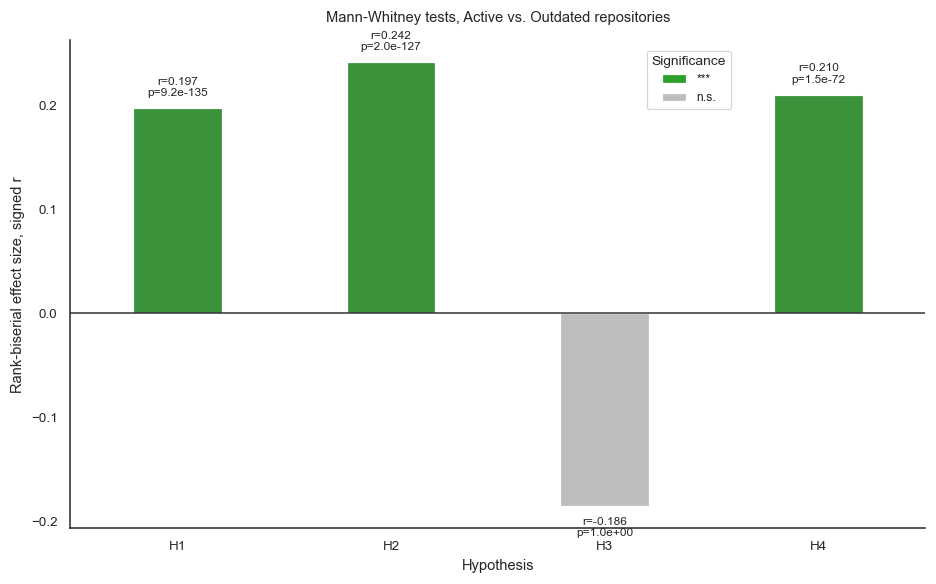

In [10]:
# ── Figure 09: formal hypothesis tests, Active vs. Outdated ──────────────────
from scipy import stats as scipy_stats
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

_active = repos_hpa[repos_hpa['is_active'] == True]
_outdated = repos_hpa[repos_hpa['is_outdated'] == True]

TESTS = [
    ('v2_ratio', 'H1', 'Higher v2_ratio in active repositories'),
    ('behavior_any', 'H2', 'Higher behavior rate in active repositories'),
    ('stargazers_count', 'H3', 'Higher stars in active repositories'),
    ('metrics_count', 'H4', 'More metrics in active repositories'),
]

print(f'{"Hypothesis":<10} {"Description":<45} {"med_A":>8} {"med_O":>8} {"p-value":>12} {"effect_r":>10}')
print('-' * 105)

rows = []
for col, hcode, hyp_desc in TESTS:
    if col not in repos_hpa.columns:
        print(f'{hcode:<10} {hyp_desc:<45} [column unavailable]')
        continue
    a = _active[col].dropna().astype(float)
    o = _outdated[col].dropna().astype(float)
    if len(a) < 3 or len(o) < 3:
        print(f'{hcode:<10} {hyp_desc:<45} [insufficient data]')
        continue
    stat, p_val = scipy_stats.mannwhitneyu(a, o, alternative='greater')
    n_a = len(a); n_o = len(o)
    mu_u = n_a * n_o / 2
    sigma_u = np.sqrt(n_a * n_o * (n_a + n_o + 1) / 12)
    z = (stat - mu_u) / sigma_u if sigma_u else np.nan
    r = z / np.sqrt(n_a + n_o) if (n_a + n_o) else np.nan
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    rows.append({'Hypothesis': hcode, 'Metric': col, 'Description': hyp_desc, 'Active median': a.median(), 'Outdated median': o.median(), 'p-value': p_val, 'effect_r': r, 'sig': sig})
    print(f'{hcode:<10} {hyp_desc:<45} {a.median():>8.3f} {o.median():>8.3f} {p_val:>12.2e} {r:>10.3f}')

res_df = pd.DataFrame(rows)
if len(res_df):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    palette = {'***': '#2ca02c', '**': '#1f77b4', '*': '#ff7f0e', 'n.s.': '#bdbdbd'}
    sns.barplot(data=res_df, x='Hypothesis', y='effect_r', hue='sig', palette=palette, dodge=False, errorbar=None, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    for patch in ax.patches:
        w = patch.get_width(); cx = patch.get_x() + w / 2; new_w = w * 0.52
        patch.set_width(new_w); patch.set_x(cx - new_w / 2)
    ax.axhline(0, color='#333333', linewidth=1.0)
    for i, row in enumerate(res_df.to_dict('records')):
        y = row['effect_r']
        p_txt = row['p-value']
        ax.text(i, y + (0.01 if y >= 0 else -0.01), f'r={y:.3f}\np={p_txt:.1e}', ha='center', va='bottom' if y >= 0 else 'top', fontsize=7.8)
    ax.set_xlabel('Hypothesis')
    ax.set_ylabel('Rank-biserial effect size, signed r')
    ax.set_title('Mann-Whitney tests, Active vs. Outdated repositories', pad=12)
    ax.legend(handles=[Patch(facecolor=palette[k], edgecolor='white', label=k) for k in ['***', '**', '*', 'n.s.'] if k in res_df['sig'].values],
              title='Significance', frameon=True, loc='upper right', bbox_to_anchor=(0.78, 0.99), fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig09_hypothesis_tests_active_vs_outdated.pdf')
    plt.show()


In [11]:
import pandas as pd

# Carregar phase4 e unir com status dos repositórios
_p4_status = p4.merge(
    repos_hpa[['repo_full_name', 'is_active', 'is_outdated']],
    on='repo_full_name', how='left'
)
_p4_status['status'] = 'In-between'
_p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
_p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
_p4_status['vg'] = _p4_status['apiVersion'].apply(map_version)

_vs = (_p4_status.groupby(['status','vg']).size().unstack(fill_value=0))
_vs_pct = _vs.div(_vs.sum(axis=1), axis=0) * 100

print("=" * 60)
print("VERSÃO POR STATUS")
print("=" * 60)
print("(linhas de métrica de phase4 unidas ao status do repositório)")
print()
_cols = [v for v in ['v1','v2beta1','v2beta2','v2'] if v in _vs_pct.columns]
_ord  = [s for s in ['Active','In-between','Outdated'] if s in _vs_pct.index]
for s in _ord:
    print(f"  {s:<12}:", end='')
    for v in _cols:
        pct = _vs_pct.loc[s,v] if v in _vs_pct.columns else 0
        print(f"  {v}={pct:.2f}%", end='')
    print()
print()

_beh_status = _p4_status.groupby('status')['has_behavior'].mean() * 100
print("Taxa de behavior por status (linhas de métrica):")
for s, r in _beh_status.items():
    print(f"  {s:<12}: {r:.2f}%")
print()

# Behavior ao nível de repositório (repos_hpa.behavior_any)
print("Taxa de behavior por status (nível de repositório, behavior_any):")
_act_r  = repos_hpa[repos_hpa['is_active']==True]
_out_r  = repos_hpa[repos_hpa['is_outdated']==True]
print(f"  Active:   {_act_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_act_r):,})")
print(f"  Outdated: {_out_r['behavior_any'].fillna(False).mean()*100:.2f}%  (n={len(_out_r):,})")
print()
print("→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%")


VERSÃO POR STATUS
(linhas de métrica de phase4 unidas ao status do repositório)

  Active      :  v1=6.20%  v2beta1=0.99%  v2beta2=3.36%  v2=89.43%
  In-between  :  v1=26.89%  v2beta1=5.38%  v2beta2=15.63%  v2=52.10%
  Outdated    :  v1=30.71%  v2beta1=30.97%  v2beta2=29.35%  v2=8.89%

Taxa de behavior por status (linhas de métrica):
  Active      : 44.95%
  In-between  : 11.09%
  Outdated    : 4.40%

Taxa de behavior por status (nível de repositório, behavior_any):
  Active:   38.26%  (n=4,955)
  Outdated: 4.28%  (n=1,356)

→ Artigo: Active=88.6% v2; Outdated=9.4% v2 | behavior Active=37.4% vs Outdated=4.8%


/tmp/ipykernel_152037/1403368753.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_active'].fillna(False).astype(bool),   'status'] = 'Active'
/tmp/ipykernel_152037/1403368753.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _p4_status.loc[_p4_status['is_outdated'].fillna(False).astype(bool), 'status'] = 'Outdated'
/tmp/ipykernel_152037/1403368753.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) inst

### 4.1 Reading the active against outdated comparison

The previous cell prints the medians, the `p` values, and the effect sizes for hypotheses H1 to H4. The figure `fig09_hypothesis_tests_active_vs_outdated.pdf` summarizes the effect size per hypothesis.

The main reading is that repository activity is associated with the adoption of `autoscaling/v2`, the use of `spec.behavior`, and the presence of more metrics. The hypothesis based on stars deserves caution, since accumulated popularity does not necessarily amount to recent maintenance.

The next cell prints the version distribution per status and the `spec.behavior` rate, both at the metric-row level and at the repository level.


## 5. HFRS and repository activity (RQ3)

This section checks whether configurations with a higher HFRS are associated with more active repositories. The HFRS summarizes HPA configuration richness, while the repository status approximates the recency of maintenance.

The next cell computes the HFRS statistics per status and produces the figure `fig17a_hfrs_by_repository_status.pdf`. The minimal version keeps only the figure the paper needs, rather than every exploratory decomposition of the full notebook.

The analysis should be read as an association and not as causality. Active repositories may show a higher HFRS because their teams maintain the configurations better, but it is also possible that more recent projects started from more modern API defaults.


Active vs. Outdated HFRS: U=9941384, p=9.17e-296, r=-0.545
              count  mean  median
repo_status                      
Active       7021.0  6.66     6.0
In-between    910.0  4.39     4.0
Outdated     1833.0  3.96     3.0
Salvo: data/figures/notebook-3/fig17a_hfrs_by_repository_status.pdf
Figure 17A displayed and saved as PDF.


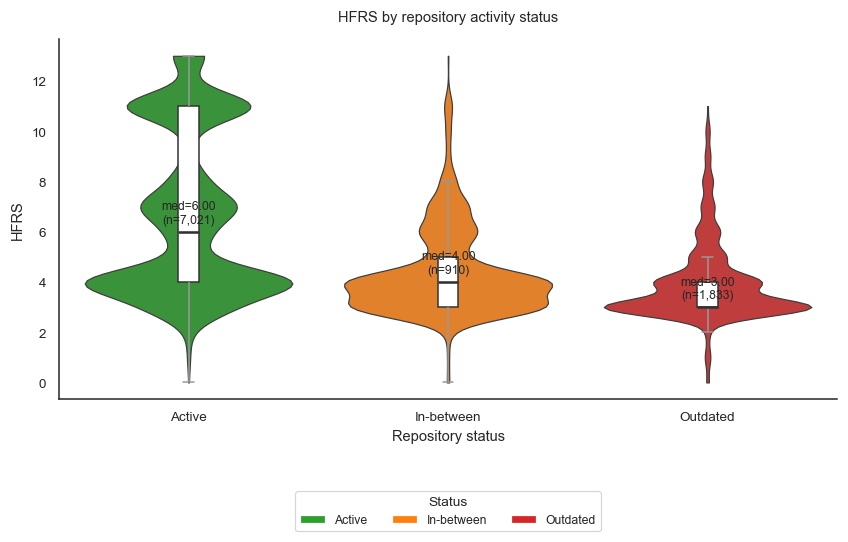

In [12]:
# ── Figure 17: HFRS × repository activity (RQ3), split PDF figures ───────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

sns.set_theme(style='white', context='paper')

_hfrs_repo_path = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_repo_path.exists():
    print('hpa_hfrs_full.csv not found. Run NB1 first.')
else:
    hfrs_repo = pd.read_csv(_hfrs_repo_path)
    if 'hpa_file_age_years' not in hfrs_repo.columns and 'hpa_file_age_y' in hfrs_repo.columns:
        hfrs_repo['hpa_file_age_years'] = hfrs_repo['hpa_file_age_y']
    if 'repo_status' not in hfrs_repo.columns:
        hfrs_repo['repo_status'] = 'In-between'
        hfrs_repo.loc[hfrs_repo['is_active'] == True, 'repo_status'] = 'Active'
        hfrs_repo.loc[hfrs_repo['is_outdated'] == True, 'repo_status'] = 'Outdated'

    STATUS_ORDER = ['Active', 'In-between', 'Outdated']
    STATUS_COLORS = {'Active': '#2ca02c', 'In-between': '#ff7f0e', 'Outdated': '#d62728'}
    RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
    RICHNESS_COLORS = {
        'Minimal': '#aec7e8', 'Basic': '#74c476', 'Moderate': '#fd8d3c',
        'Rich': '#e6550d', 'Highly Rich': '#756bb1'
    }

    act = hfrs_repo.loc[hfrs_repo['repo_status'].eq('Active'), 'HFRS'].dropna()
    out = hfrs_repo.loc[hfrs_repo['repo_status'].eq('Outdated'), 'HFRS'].dropna()
    u, p = stats.mannwhitneyu(act, out, alternative='greater')
    r_effect = 1 - 2*u/(len(act)*len(out))
    print(f'Active vs. Outdated HFRS: U={u:.0f}, p={p:.2e}, r={r_effect:.3f}')
    print(hfrs_repo.groupby('repo_status')['HFRS'].describe()[['count', 'mean', '50%']].rename(columns={'50%': 'median'}).round(2))

    # Figure 17A
    plot_df = hfrs_repo.dropna(subset=['HFRS', 'repo_status']).copy()
    plot_df = plot_df[plot_df['repo_status'].isin(STATUS_ORDER)]
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    sns.violinplot(data=plot_df, x='repo_status', y='HFRS', order=STATUS_ORDER, hue='repo_status',
                   palette=STATUS_COLORS, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x='repo_status', y='HFRS', order=STATUS_ORDER, width=0.08, color='white',
                showfliers=False, boxprops={'facecolor': 'white', 'edgecolor': '#333333'},
                medianprops={'color': '#333333', 'linewidth': 1.7}, ax=ax)
    for i, s in enumerate(STATUS_ORDER):
        vals = plot_df.loc[plot_df['repo_status'].eq(s), 'HFRS']
        if len(vals):
            ax.text(i, vals.median() + 0.22, f'med={vals.median():.2f}\n(n={len(vals):,})', ha='center', va='bottom', fontsize=8.0)
    ax.set_xlabel('Repository status')
    ax.set_ylabel('HFRS')
    ax.set_title('HFRS by repository activity status', pad=12)
    ax.legend(handles=[Patch(facecolor=STATUS_COLORS[s], edgecolor='white', label=s) for s in STATUS_ORDER],
              title='Status', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3, fontsize=8.0, title_fontsize=9.0)
    sp(ax); ax.grid(False)
    plt.tight_layout()
    savefig('fig17a_hfrs_by_repository_status.pdf')
print('Figure 17A displayed and saved as PDF.')


## 6. Sensitivity of the version distribution

This section checks whether the distribution of HPA API versions changes when the corpus is filtered by activity, age, the toy-project signal, repository lifespan, and popularity.

The analysis addresses the following threat to validity: the results on version adoption may depend on the filter used to define the analyzed corpus.

Scenarios considered:

| Scenario | Additional criterion | Purpose |
|---|---|---|
| All data | No additional filter | Baseline |
| Active | Repositories with recent activity | Focus on maintained projects |
| Active + created <= 5yr | Active and recently created | Focus on modern projects |
| Active + no toy flag | Active without the toy signal | Reduces educational noise |
| Active + lifespan > 6mo | Active and not ephemeral | Removes very short-lived repositories |
| Active + stars >= 1 | Active with at least one star | Minimum visibility filter |

The values are printed by the next cell and used as the sensitivity table for the paper.


In [13]:
# ── Consolidar métrica ─────────────────────────────────────

cutoff_5yr = REF_DATE - pd.DateOffset(years=5)
p4_5yr = p4_files[p4_files['pushed_age_years'] <= 5]

summary = {
    # ── Corpus bruto
    'Total repos in hpa_repo_aggregated':              len(repos),
    'Repos with HPA data (phase3/4)':                  len(repos_hpa),
    'Repos without HPA data (phase3/4 found nothing)': (~repos['has_hpa_data']).sum(),

    # ── Arquivos HPA (phase4)
    'Total HPA files (phase4, no Helm)':               len(p4_files),
    'HPA files with pushed_at <= 5yr':                 len(p4_5yr),
    'HPA files excluded by 5yr filter':                len(p4_files) - len(p4_5yr),

    # ── Toy signal
    'HPA files with toy keyword in name':              p4_files['toy_any'].fillna(False).sum(),
    '% toy-flagged':                                   f'{p4_files["toy_any"].fillna(False).mean()*100:.2f}%',

    # ── Versões (sem filtro adicional)
    'v1 files':                                        (p4_files['VersionGroup']=='v1').sum(),
    'v2beta1 files':                                   (p4_files['VersionGroup']=='v2beta1').sum(),
    'v2beta2 files':                                   (p4_files['VersionGroup']=='v2beta2').sum(),
    'v2 files':                                        (p4_files['VersionGroup']=='v2').sum(),
    '% v2 (stable)':                                   f'{(p4_files["VersionGroup"]=="v2").mean()*100:.2f}%',

    # ── Padrão stable HPA
    'Active repos (pushed <= 2yr) total files':        total_active,
    'Stable HPA pattern (non-v2, v2_ratio=0, active)': len(stable_hpa_active_repo),
    '% stable HPA within active repos':                f'{len(stable_hpa_active_repo)/total_active*100:.2f}%',

    # ── Datas de referência
    'Reference date (collection)':                     str(REF_DATE.date()),
    '5yr cutoff date':                                  str(cutoff_5yr.date()),
}

_s = pd.Series(summary, name='Value')
print(_s.to_frame().to_string())

                                                      Value
Total repos in hpa_repo_aggregated                    12741
Repos with HPA data (phase3/4)                         7013
Repos without HPA data (phase3/4 found nothing)        5728
Total HPA files (phase4, no Helm)                      9764
HPA files with pushed_at <= 5yr                        9385
HPA files excluded by 5yr filter                        379
HPA files with toy keyword in name                     1298
% toy-flagged                                        13.29%
v1 files                                               1699
v2beta1 files                                           623
v2beta2 files                                           961
v2 files                                               6478
% v2 (stable)                                        66.35%
Active repos (pushed <= 2yr) total files               7758
Stable HPA pattern (non-v2, v2_ratio=0, active)         729
% stable HPA within active repos        

## 7. Smell indicators (RQ4)

This section computes a catalogue of indicators that identify potentially problematic patterns in HPA configurations. The indicators are descriptive. The presence of an indicator does not imply an error by itself, but marks files that deserve closer technical review.

Indicators computed:

| Indicator | Criterion | Associated concern |
|---|---|---|
| **R1** | `apiVersion = v1` in an active repository | Active use of a legacy API |
| **R2** | `apiVersion = v2*` and `HFRS <= 4` | Nominal v2 adoption with low configuration richness |
| **R3** | Old HPA file in an active repository | Potentially frozen configuration |
| **R4** | `minReplicas = maxReplicas` | HPA with no actual scaling range |
| **R5** | `spec.behavior` under an API that does not support it | Inconsistency between fields and declared version |
| **R6** | `cpu.averageUtilization < 10%` | Potentially aggressive CPU threshold |
| **R7** | `SR >= 3` and `CR = 0` | Rich signals with no explicit control policies |
| **R8** | `SR >= 3` and `AR <= 2` | Rich signals with low proportional adjustment |

Indicators R1 to R6 correspond to the six configuration smells reported in the paper, from S1 to S6. R7 and R8 are additional checks kept for the analysis.

The next cell prints the summary table with the count, the prevalence, the mean HFRS, and the share of active files per indicator. It also prints the distribution of `risk_count_all`, which records how many indicators occur at once in the same HPA file.


In [14]:
# ── Figure 24: risk indicators, split PDF figures ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
p4 = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
hfrs = pd.read_csv(DATA_DIR / 'hpa_hfrs.csv')
agg = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
p3c = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')

REF_DATE = pd.Timestamp('2026-03-07', tz='UTC')
V1_ALIASES = {'autoscaling/v1', 'v1', 'autoscaling/V1'}
INVALID_BEHAVIOR = {'autoscaling/v1', 'v1', 'autoscaling/V1', 'autoscaling/v2beta1'}

hfrs['repo_full_name'] = hfrs['Owner'] + '/' + hfrs['Project']
merged = hfrs.merge(
    agg[['repo_full_name', 'stargazers_count', 'is_active', 'is_outdated', 'pushed_at']],
    on='repo_full_name', how='left'
)
p3c['repo_full_name'] = p3c['Owner'] + '/' + p3c['Project']
merged = merged.merge(
    p3c[['Owner', 'Project', 'File Path', 'file_last_commit']],
    on=['Owner', 'Project', 'File Path'], how='left'
)

merged['repo_status'] = 'In-between'
merged.loc[merged['is_active'] == True, 'repo_status'] = 'Active'
merged.loc[merged['is_outdated'] == True, 'repo_status'] = 'Outdated'
merged['file_last_commit'] = pd.to_datetime(merged['file_last_commit'], utc=True, errors='coerce')
merged['hpa_file_age_y'] = (REF_DATE - merged['file_last_commit']).dt.days / 365.25

p4_pf = p4.groupby(['Owner', 'Project', 'File Path']).first().reset_index()
r4_df = p4_pf[p4_pf['MinReplicas'].astype(str) == p4_pf['MaxReplicas'].astype(str)]
r4_keys = set(zip(r4_df['Owner'], r4_df['Project'], r4_df['File Path']))
low_cpu = p4[
    (p4['Metric Name'].fillna('').str.lower() == 'cpu') &
    (p4['Target Kind'].fillna('') == 'Utilization') &
    (pd.to_numeric(p4['Target Value'], errors='coerce') < 10)
].copy()
r6_keys = set(zip(low_cpu['Owner'], low_cpu['Project'], low_cpu['File Path']))

merged['R1'] = merged['apiVersion'].isin(V1_ALIASES) & merged['repo_status'].eq('Active')
merged['R2'] = (~merged['apiVersion'].isin(V1_ALIASES)) & (merged['HFRS'] <= 4)
merged['R3'] = merged['repo_status'].eq('Active') & (merged['hpa_file_age_y'] > 2)
merged['R4'] = merged.apply(lambda r: (r['Owner'], r['Project'], r['File Path']) in r4_keys, axis=1)
merged['R5'] = merged['apiVersion'].isin(INVALID_BEHAVIOR) & (merged['CR1'] == 1)
merged['R6'] = merged.apply(lambda r: (r['Owner'], r['Project'], r['File Path']) in r6_keys, axis=1)
merged['R7'] = (merged['SR'] >= 3) & (merged['CR'] == 0)
merged['R8'] = (merged['SR'] >= 3) & (merged['AR'] <= 2)

risk_cols_all = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
risk_names = {
    'R1': 'API v1 in active repo',
    'R2': 'v2 minimal, HFRS≤4',
    'R3': 'Frozen HPA in active repo',
    'R4': 'minReplicas = maxReplicas',
    'R5': 'behavior in unsupported API',
    'R6': 'CPU target < 10%',
    'R7': 'SR≥3 without behavior',
    'R8': 'SR≥3 with low calibration',
}
RISK_COLORS = {
    'R1': '#d62728', 'R2': '#ff7f0e', 'R3': '#9467bd', 'R4': '#1f77b4',
    'R5': '#2ca02c', 'R6': '#8c564b', 'R7': '#e377c2', 'R8': '#7f7f7f'
}

merged['risk_count_all'] = merged[risk_cols_all].sum(axis=1)
summary_rows = []
print('=== TABELA RESUMO — todos os indicadores de risco ===')
for col in risk_cols_all:
    mask = merged[col]
    n = int(mask.sum())
    pct = n / len(merged) * 100
    mean_hfrs = merged.loc[mask, 'HFRS'].mean() if n else np.nan
    active_pct = merged.loc[mask, 'repo_status'].eq('Active').mean() * 100 if n else np.nan
    summary_rows.append({
        'Indicator': col,
        'Description': risk_names[col],
        'Files': n,
        'Share (%)': pct,
        'Mean HFRS': mean_hfrs,
        'Active (%)': active_pct,
    })
    print(f'  {col} — {risk_names[col]:<32} {n:>5,} ({pct:>5.2f}%) | mean HFRS={mean_hfrs:>5.2f} | active={active_pct:>5.2f}%')

summary_df = pd.DataFrame(summary_rows)
print('\nRisk-count distribution, R1-R8:')
print(merged['risk_count_all'].value_counts().sort_index().to_string())
print(f"\nFiles without any indicator: {(merged['risk_count_all'] == 0).sum():,} ({(merged['risk_count_all'] == 0).mean()*100:.2f}%)")
print(f"Files with two or more indicators: {(merged['risk_count_all'] >= 2).sum():,} ({(merged['risk_count_all'] >= 2).mean()*100:.2f}%)")


print('\nRisk indicators table used for article consistency checks:')
display(summary_df)

print('\nR6 denominator check:')
print(f"  CPU metric entries with target < 10%: {len(low_cpu):,}")
print(f"  Unique HPA files affected by R6: {len(r6_keys):,}")


=== TABELA RESUMO — todos os indicadores de risco ===
  R1 — API v1 in active repo              728 ( 7.46%) | mean HFRS= 3.02 | active=100.00%
  R2 — v2 minimal, HFRS≤4               3,480 (35.64%) | mean HFRS= 3.81 | active=67.70%
  R3 — Frozen HPA in active repo           56 ( 0.57%) | mean HFRS= 3.52 | active=100.00%
  R4 — minReplicas = maxReplicas          445 ( 4.56%) | mean HFRS= 3.93 | active=70.56%
  R5 — behavior in unsupported API         14 ( 0.14%) | mean HFRS= 6.64 | active=78.57%
  R6 — CPU target < 10%                   140 ( 1.43%) | mean HFRS= 4.13 | active=66.43%
  R7 — SR≥3 without behavior            1,712 (17.53%) | mean HFRS= 6.68 | active=77.75%
  R8 — SR≥3 with low calibration          139 ( 1.42%) | mean HFRS= 5.37 | active=28.78%

Risk-count distribution, R1-R8:
risk_count_all
0    3717
1    5415
2     599
3      31
4       2

Files without any indicator: 3,717 (38.07%)
Files with two or more indicators: 632 (6.47%)

Risk indicators table used for article co

,Indicator,Description,Files,Share (%),Mean HFRS,Active (%)
0,R1,API v1 in active repo,728,7.455961,3.019231,100.000000
1,R2,"v2 minimal, HFRS≤4",3480,35.641131,3.811782,67.701149
2,R3,Frozen HPA in active repo,56,0.573535,3.517857,100.000000
3,R4,minReplicas = maxReplicas,445,4.557558,3.932584,70.561798
4,R5,behavior in unsupported API,14,0.143384,6.642857,78.571429
5,R6,CPU target < 10%,140,1.433839,4.128571,66.428571
6,R7,SR≥3 without behavior,1712,17.533798,6.682827,77.745327
7,R8,SR≥3 with low calibration,139,1.423597,5.374101,28.776978



R6 denominator check:
  CPU metric entries with target < 10%: 143
  Unique HPA files affected by R6: 140


## 8. HFRS sensitivity per filtering scenario

This section applies to the HFRS the same sensitivity logic used for the version distribution. It checks whether the configuration richness changes substantially when the corpus is filtered by activity, HPA file age, popularity, or commit year.

Scenarios considered:

| Scenario | Criterion |
|---|---|
| All data | Full corpus |
| Active | Active repositories only |
| HPA <= 2yr | Recently modified HPA files |
| Stars > 0 | Repositories with at least one star |
| Stars >= 10 | Repositories with higher visibility |
| Year >= 2024 | Files with a recent commit |

The next cell prints the sensitivity table with the file count, the mean and median HFRS, and the shares of the Basic and Rich+ classes. The values are not duplicated in the markdown, which avoids inconsistency with future runs.


In [15]:
# ── Figure 18: HFRS sensitivity by filtering scenario, split PDF figures ──────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'
if not _hfrs_full.exists():
    print('hpa_hfrs_full.csv not found.')
else:
    hf = pd.read_csv(_hfrs_full)
    hf['commit_year'] = pd.to_numeric(hf['commit_year'], errors='coerce')
    hf['stargazers_count'] = pd.to_numeric(hf['stargazers_count'], errors='coerce')

    RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']
    RICHNESS_COLORS = {
        'Minimal': '#aec7e8', 'Basic': '#74c476', 'Moderate': '#fd8d3c',
        'Rich': '#e6550d', 'Highly Rich': '#756bb1'
    }

    scenarios = {
        'All data': hf,
        'Active': hf[hf['repo_status'] == 'Active'],
        'HPA ≤2yr': hf[hf['hpa_file_age_y'] <= 2],
        'Stars > 0': hf[hf['stargazers_count'] > 0],
        'Stars ≥ 10': hf[hf['stargazers_count'] >= 10],
        'Year ≥ 2024': hf[hf['commit_year'] >= 2024],
    }

    rows = []
    for name, df in scenarios.items():
        df_c = df.dropna(subset=['HFRS']).copy()
        rc = df_c['richness_class'].value_counts()
        rows.append({
            'Scenario': name,
            'Files': len(df_c),
            'Mean HFRS': df_c['HFRS'].mean(),
            'Median HFRS': df_c['HFRS'].median(),
            'Basic (%)': rc.get('Basic', 0) / len(df_c) * 100 if len(df_c) else 0,
            'Rich+ (%)': (rc.get('Rich', 0) + rc.get('Highly Rich', 0)) / len(df_c) * 100 if len(df_c) else 0,
        })
    tbl = pd.DataFrame(rows)
    print(tbl.round(2).to_string(index=False))


print('\nHFRS sensitivity table used by the article:')
display(tbl)


   Scenario  Files  Mean HFRS  Median HFRS  Basic (%)  Rich+ (%)
   All data   9764       5.94          4.0      55.65      20.95
     Active   7021       6.66          6.0      45.92      28.10
   HPA ≤2yr   7090       6.65          6.0      46.05      27.86
  Stars > 0   2720       5.91          4.0      55.04      20.26
 Stars ≥ 10    600       5.10          4.0      66.67      12.50
Year ≥ 2024   7286       6.59          6.0      46.95      27.22

HFRS sensitivity table used by the article:


,Scenario,Files,Mean HFRS,Median HFRS,Basic (%),Rich+ (%)
0,All data,9764,5.942032,4.0,55.653421,20.954527
1,Active,7021,6.660020,6.0,45.919385,28.101410
2,HPA ≤2yr,7090,6.647532,6.0,46.050776,27.856135
3,Stars > 0,2720,5.909926,4.0,55.036765,20.257353
4,Stars ≥ 10,600,5.103333,4.0,66.666667,12.500000
5,Year ≥ 2024,7286,6.585506,6.0,46.953061,27.216580


## 9. Commit frequency on HPA files (Phase 6)

This section uses Phase 6 to analyze how often HPA files were modified in the sampled repositories. The phase distinguishes general repository commit events from events that touched HPA files specifically.

Main measures:

| Measure | Interpretation |
|---|---|
| `hpa_touch_count` | Number of commits that touched HPA files per repository |
| `repo_commit_count` | Number of general repository commits in the sample |
| `hpa_touch_rate` | Relative frequency of HPA commits against the repository commits |

The next cell prints the distribution of `hpa_touch_count` and its Spearman correlation with the HFRS. The minimal version keeps the output the paper relies on and leaves out the exploratory figures of the full notebook.


In [16]:
# ── Figure 22: HPA-touch frequency and yearly evolution, split PDF figures ────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_p6_path = DATA_DIR / 'phase6_commit_timeline_latest.csv'
_hfrs_full = DATA_DIR / 'hpa_hfrs_full.csv'

if not _p6_path.exists():
    print('phase6_commit_timeline_latest.csv not found.')
else:
    p6 = pd.read_csv(_p6_path)
    hf = pd.read_csv(_hfrs_full)
    p6['commit_date'] = pd.to_datetime(p6['commit_date'], utc=True, errors='coerce')
    p6['commit_year'] = p6['commit_date'].dt.year
    hpa_commits = p6[p6['commit_type'] == 'hpa_file'].copy()
    repo_commits = p6[p6['commit_type'] == 'repo'].copy()

    touch_freq = hpa_commits.groupby('repo_full_name').size().reset_index(name='hpa_touch_count')
    repo_freq = repo_commits.groupby('repo_full_name').size().reset_index(name='repo_commit_count')
    timeline_df = touch_freq.merge(repo_freq, on='repo_full_name', how='outer').fillna(0)
    timeline_df['hpa_touch_rate'] = timeline_df['hpa_touch_count'] / (timeline_df['repo_commit_count'] + 1)
    hf_repo = hf.groupby('repo_full_name')['HFRS'].mean().reset_index()
    timeline_df = timeline_df.merge(hf_repo, on='repo_full_name', how='left')

    rho, p_val = stats.spearmanr(timeline_df.dropna(subset=['hpa_touch_count', 'HFRS'])['hpa_touch_count'], timeline_df.dropna(subset=['hpa_touch_count', 'HFRS'])['HFRS'])
    print(f'Spearman hpa_touch_count × HFRS: rho={rho:.3f}, p={p_val:.3f}')
    print(touch_freq['hpa_touch_count'].describe().round(2))


print('\nPhase 6 summary used by the article:')
print(f"  repositories with HPA-file commits: {hpa_commits['repo_full_name'].nunique():,}")
print(f"  HPA-file events: {len(hpa_commits):,}")
print(f"  repository-level events: {len(repo_commits):,}")


Spearman hpa_touch_count × HFRS: rho=0.078, p=0.311
count    169.00
mean       1.54
std        1.41
min        1.00
25%        1.00
50%        1.00
75%        1.00
max       11.00
Name: hpa_touch_count, dtype: float64

Phase 6 summary used by the article:
  repositories with HPA-file commits: 169
  HPA-file events: 261
  repository-level events: 8,665


## 10. Temporal co-evolution between HPA commits and repository commits

This section analyzes whether changes to HPA files happen together with general repository commits or appear as changes isolated in time.

Method:

1. for each `hpa_file` event, identify the general commit of the same repository that is closest in time;
2. compute the smallest absolute difference in days;
3. a difference of zero indicates that the HPA change happened in the same commit as other repository changes;
4. larger differences indicate HPA changes that are temporally isolated.

The next cell prints the number of pairs analyzed, the number of unique repositories, and the share of events at distances of 0, 1, 7, 30, and 90 days.


In [17]:
# ── Figure 23: temporal co-evolution of HPA commits, split PDF figures ───────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')

DATA_DIR = Path('data')
_coev_path = DATA_DIR / 'phase6_coevolution.csv'
if not _coev_path.exists():
    print('phase6_coevolution.csv not found.')
else:
    df_coev = pd.read_csv(_coev_path)
    print(f'Pairs analysed: {len(df_coev):,}')
    print(f'Unique repositories: {df_coev["repo"].nunique():,}')
    for t in [0, 1, 7, 30, 90]:
        n = (df_coev['min_diff_days'] <= t).sum()
        print(f'<= {t} days: {n:,} ({n/len(df_coev)*100:.2f}%)')

    vals = pd.to_numeric(df_coev['min_diff_days'], errors='coerce').fillna(0)
    n_zero = int((vals == 0).sum())
    n_pos = int((vals > 0).sum())
    df_nonzero = df_coev[df_coev['min_diff_days'] > 0].copy()


vals = pd.to_numeric(df_coev['min_diff_days'], errors='coerce').fillna(0)
n_zero = int((vals == 0).sum())
n_pos = int((vals > 0).sum())
print('\nCo-evolution summary used by the article:')
print(f"  pairs analysed: {len(df_coev):,}")
print(f"  unique repositories: {df_coev['repo'].nunique():,}")
print(f"  same-commit pairs: {n_zero:,} ({n_zero/len(df_coev)*100:.2f}%)")
print(f"  isolated pairs: {n_pos:,} ({n_pos/len(df_coev)*100:.2f}%)")
if n_pos:
    print(f"  median distance for isolated pairs: {vals[vals > 0].median():.0f} days")


Pairs analysed: 241
Unique repositories: 155
<= 0 days: 157 (65.15%)
<= 1 days: 157 (65.15%)
<= 7 days: 157 (65.15%)
<= 30 days: 159 (65.98%)
<= 90 days: 161 (66.80%)

Co-evolution summary used by the article:
  pairs analysed: 241
  unique repositories: 155
  same-commit pairs: 225 (93.36%)
  isolated pairs: 16 (6.64%)
  median distance for isolated pairs: 269 days


## 11. Final check

This cell confirms that the main artifacts expected from the minimal version were produced. It is a simple check that avoids ending the run without the files the paper relies on.


In [18]:
expected_figures = [
    'fig17a_hfrs_by_repository_status.pdf',
]

print('Expected figures for the minimal Notebook 3 version:')
missing = []
for name in expected_figures:
    path = PLOTS_DIR / name
    status = 'OK' if path.exists() else 'missing'
    print(f'  {name:<48} {status}')
    if not path.exists():
        missing.append(name)

if missing:
    raise FileNotFoundError('Missing expected figures: ' + ', '.join(missing))

print('')
print('Minimal Notebook 3 verification completed.')
print('The remaining article-support artifacts in this version are printed tables for:')
print('- frozen HPA pattern')
print('- active vs. outdated comparison')
print('- version distribution by repository status')
print('- risk indicators R1-R8')
print('- HFRS sensitivity')
print('- Phase 6 HPA-touch frequency')
print('- commit co-evolution')


Expected figures for the minimal Notebook 3 version:
  fig17a_hfrs_by_repository_status.pdf             OK

Minimal Notebook 3 verification completed.
The remaining article-support artifacts in this version are printed tables for:
- frozen HPA pattern
- active vs. outdated comparison
- version distribution by repository status
- risk indicators R1-R8
- HFRS sensitivity
- Phase 6 HPA-touch frequency
- commit co-evolution
